# World Cup 2026: an honest expected-goals chart, and the one profile that survives it

A debate I kept circling back to while rebuilding this chart was really a question of what a graph claims to show versus what it measures underneath, which I found compelling in the same way the LBJ and Biden approval graphs were, where the surface reading and the real story pull apart once you look closer.

The chart I started with came from footballytics, plotting World Cup 2026 attackers along a blended vertical axis of 0.3 times goals plus 0.7 times xG per 90, and I thought the underlying concept worked well enough, since two axes sort scorers from creators, though the execution had three problems I found serious enough to rebuild the whole thing around.

**The vertical axis measured the wrong thing.** It was labeled finishing quality, but a blend of goals and xG tracks shot volume and chance quality, not finishing, so a high-volume shooter posts a big number whether or not he converts. Genuine finishing is goals minus xG, the overperformance a player generates beyond his chances, so I moved the vertical axis to goals minus xG.

**Creation needed the right metric.** I used xA on the horizontal axis, because xA credits the quality of the chance a player builds and does not punish a creator whose teammates fail to finish, so it isolates the creation a player controls from the conversion he does not.

**Small samples were treated as equal.** A World Cup gives each player only a handful of games, and the original weighted a cameo the same as a starter, so I applied a minutes-and-output floor and sized every dot by shots, so a small sample shows up as a small dot you read with more caution.

### Who is in the set, and why the rule is symmetric

The inclusion rule is: a player is in if he generated **1.3 or more expected goals (xG) OR 1.3 or more expected assists (xA)** across the tournament. Both gates use the same unit, expected goals, one pointed at scoring and one at creating, so the two sides are directly comparable. This deliberately keeps two kinds of player a one-sided rule would drop: pure finishers who shoot but rarely create, and pure creators who create but rarely shoot.

One deliberate choice worth flagging: the gates use xG and xA, not goals and assists. That mirrors the analysis itself, which trusts xG over goals because outcomes over five games are noisy while expected values are the stabler signal. A player with four assists on 0.9 xA is mostly the creation-side mirror of a lucky finisher, teammate conversion and variance rather than creation skill, though a persistent assists-over-xA gap can also reflect creation a model underrates. Over a five-game sample the noise reading dominates, so gating on xA is the honest call.

Finishing figures come from FIFA's official tournament stats; creation (xA) from FotMob. Each axis is single-source, so no metric mixes providers.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
df = pd.read_csv("wc2026_attackers.csv")
df["finishing"] = df["goals"] - df["xg_total"]   # overperformance = true finishing
df.sort_values("xa_total", ascending=False).head()

,name,goals,xg_total,shots,xa_total,minutes,finishing
1,Messi,8,6.18,35,4.2,762,1.82
11,Olise,0,2.34,20,3.3,666,-2.34
12,Dembele,6,2.10,20,2.3,596,3.90
14,Pedri,0,0.47,5,2.2,600,-0.47
13,Trossard,2,1.67,17,2.2,515,0.33


## Chart 1: finishing versus creation, sized by shots

Vertical axis is finishing (goals minus xG). Horizontal is creation (total xA). Dot size is shots taken. No quadrant labels, no verdicts: where a player sits is the information. What the next section adds is how firmly each of the two readings can be pushed.

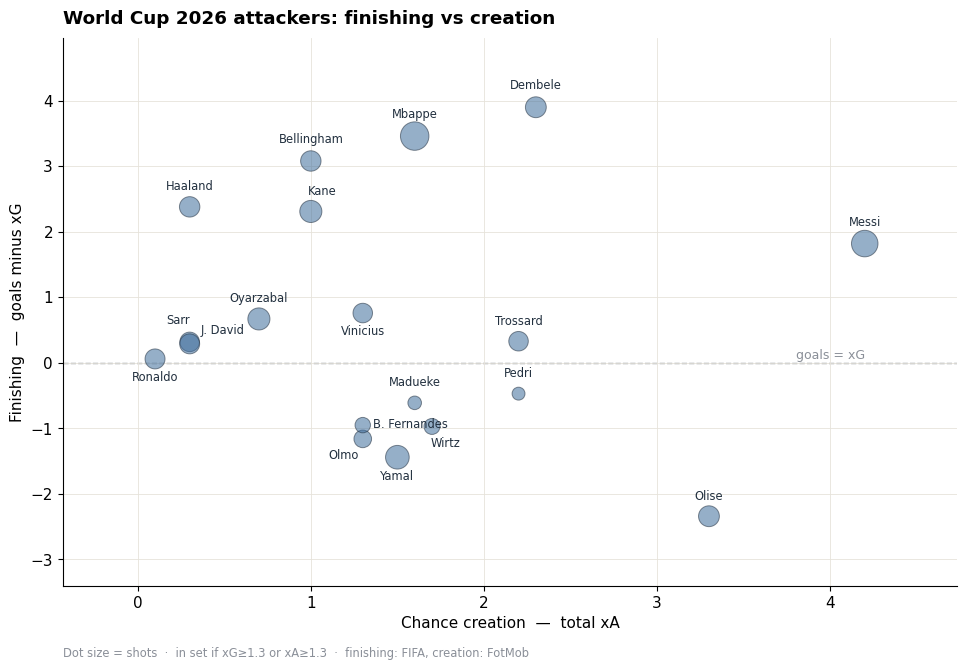

In [2]:
INK,ACC,MUT,GRID="#22303f","#3f6d9c","#8a8f98","#e6e3db"
plt.rcParams.update({"font.size":11,"figure.facecolor":"white","axes.facecolor":"white"})
# CHART 1
fig,ax=plt.subplots(figsize=(9.8,6.8))
sz=(df["shots"]/df["shots"].max()*380)+40
ax.scatter(df["xa_total"],df["finishing"],s=sz,color=ACC,alpha=.55,edgecolor=INK,lw=.7,zorder=3)
ax.axhline(0,color=MUT,lw=1,ls="--",zorder=1)
ax.text(df["xa_total"].max(),.06,"goals = xG",color=MUT,fontsize=9,ha="right")
off={"Bellingham":(0,13),"Dembele":(0,13),"Kane":(8,12),"Mbappe":(0,13),"Haaland":(0,12),
 "Vinicius":(0,-16),"Trossard":(0,12),"Olmo":(-14,-14),"B. Fernandes":(34,-2),"Wirtz":(10,-15),
 "Madueke":(0,12),"Pedri":(0,12),"Olise":(0,12),"Messi":(0,13),"Yamal":(0,-16),
 "Ronaldo":(0,-16),"Jimenez":(-18,-13),"J. David":(24,7),"Sarr":(-8,13),"Oyarzabal":(0,12)}
for _,r in df.iterrows():
    dx,dy=off.get(r["name"],(0,12))
    ax.annotate(r["name"],(r["xa_total"],r["finishing"]),xytext=(dx,dy),
                textcoords="offset points",ha="center",fontsize=8.3,color=INK)
ax.set_xlabel("Chance creation  —  total xA"); ax.set_ylabel("Finishing  —  goals minus xG")
ax.set_title("World Cup 2026 attackers: finishing vs creation",fontweight="bold",loc="left",pad=10)
ax.grid(color=GRID,lw=.6,zorder=0); ax.margins(x=.13,y=.17)
ax.text(0,-.13,"Dot size = shots  ·  in set if xG≥1.3 or xA≥1.3  ·  finishing: FIFA, creation: FotMob",
        transform=ax.transAxes,fontsize=8.3,color=MUT)
for s in["top","right"]:ax.spines[s].set_visible(False)
plt.tight_layout();plt.show()



How to read it. Far right means an elite creator: Messi sits alone out there, off the largest shot sample in the set. Up top are the scorers beating their chances (Dembele, Mbappe, Bellingham). The low-centre cluster, Pedri, Wirtz, Madueke, Olmo, Bruno Fernandes, are creators who barely shoot, so their finishing sits near or below zero, which is exactly right for their role and exactly why the OR rule keeps them.

Two things are worth separating before trusting any position: how noisy the finishing axis is, and whether the creation axis is measuring something real.

## Calibrating the finishing axis

Finishing rests on rare events. A player takes only a few shots a game, each converting with a small probability, so goals minus xG sits on a handful of chances and one finish or miss swings it hard. I model goals as a sum of Bernoulli trials, one per real shot, each with probability equal to its average xG, so the standard deviation of goals minus xG is the binomial spread over the player's real shot count.

In [3]:
p = (df["xg_total"]/df["shots"]).clip(upper=0.99)      # avg per-shot xG, from real shots
df["sd_finish"] = np.sqrt(df["shots"]*p*(1-p))         # SD of goal count
df["ci95"] = 1.96*df["sd_finish"]
crosses = ((df["finishing"]-df["ci95"]<0)&(df["finishing"]+df["ci95"]>0)).sum()
print(f"{crosses} of {len(df)} finishing bands cross zero.")
df.sort_values("finishing",ascending=False)[["name","goals","xg_total","shots","finishing","ci95"]].round(2)

18 of 19 finishing bands cross zero.


,name,goals,xg_total,shots,finishing,ci95
12,Dembele,6,2.10,20,3.90,2.69
0,Mbappe,10,6.54,41,3.46,4.60
4,Bellingham,7,3.92,19,3.08,3.46
2,Haaland,7,4.62,19,2.38,3.67
5,Kane,6,3.69,23,2.31,3.45
1,Messi,8,6.18,35,1.82,4.42
7,Vinicius,4,3.24,17,0.76,3.17
3,Oyarzabal,5,4.33,23,0.67,3.67
13,Trossard,2,1.67,17,0.33,2.41
6,Sarr,4,3.68,17,0.32,3.33


Nineteen of twenty bands cross zero. That does not make the finishing axis meaningless; it tells you to read a short-tournament finishing number as what happened, not as settled skill.

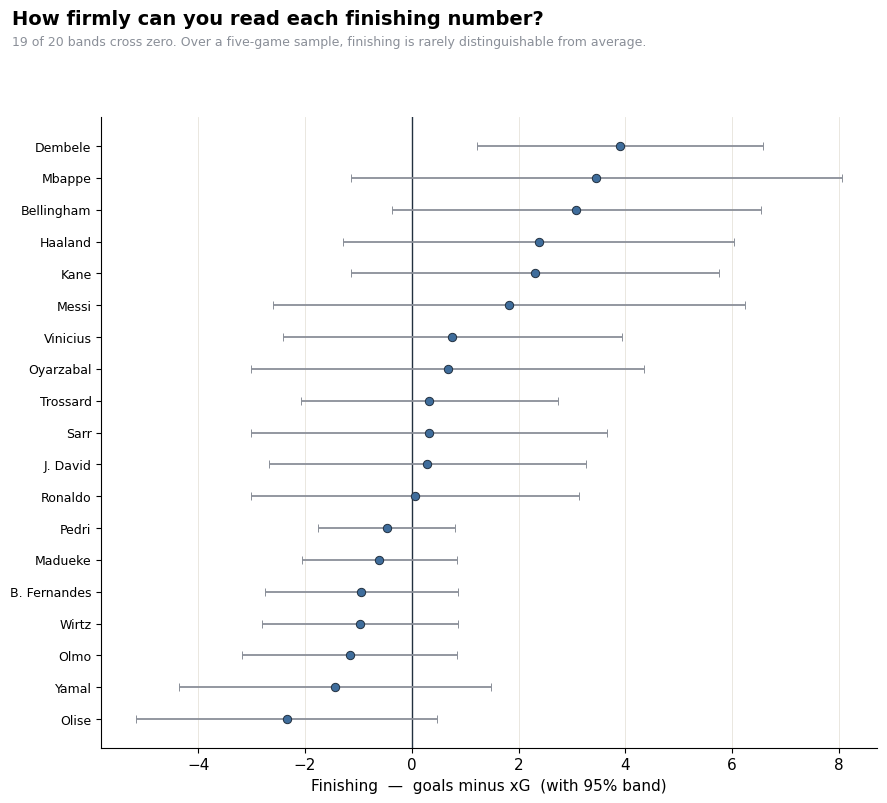

In [4]:
INK,ACC,MUT,GRID="#22303f","#3f6d9c","#8a8f98","#e6e3db"
plt.rcParams.update({"font.size":11,"figure.facecolor":"white","axes.facecolor":"white"})
# CHART 2: finishing with 95% bands
d2=df.sort_values("finishing")
fig,ax=plt.subplots(figsize=(9,8))
y=np.arange(len(d2))
ax.errorbar(d2["finishing"],y,xerr=d2["ci95"],fmt="o",color=ACC,ecolor=MUT,elinewidth=1.3,
            capsize=3,markersize=6,markeredgecolor=INK,markeredgewidth=.7,zorder=3)
ax.axvline(0,color=INK,lw=1,zorder=2)
ax.set_yticks(y);ax.set_yticklabels(d2["name"],fontsize=9)
ax.set_xlabel("Finishing  —  goals minus xG  (with 95% band)")
ax.grid(axis="x",color=GRID,lw=.6,zorder=0)
for s in["top","right"]:ax.spines[s].set_visible(False)
fig.suptitle("How firmly can you read each finishing number?",fontweight="bold",fontsize=14,x=.02,ha="left",y=1.0)
fig.text(.02,.955,"19 of 20 bands cross zero. Over a five-game sample, finishing is rarely distinguishable from average.",fontsize=9,color=MUT,ha="left")
plt.tight_layout(rect=[0,0,1,.93]);plt.show()



## Calibrating the creation axis

Creation rests on far more events than finishing (chances created happen many times per game), so xA is the stabler of the two axes. But is it measuring real creation or teammate luck? Plotting xA against actual assists answers it: on the diagonal, a player's chances converted as expected.

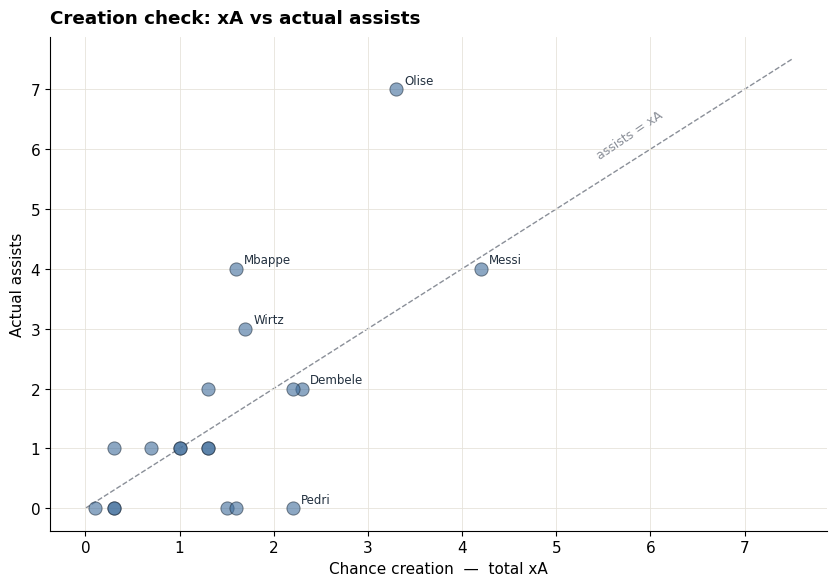

In [5]:
INK,ACC,MUT,GRID="#22303f","#3f6d9c","#8a8f98","#e6e3db"
plt.rcParams.update({"font.size":11,"figure.facecolor":"white","axes.facecolor":"white"})
# CHART 3: xA vs actual assists (creation calibration)
assists={"Messi":4,"Olise":7,"Dembele":2,"Trossard":2,"Pedri":0,"Wirtz":3,"Madueke":0,
 "Olmo":2,"B. Fernandes":1,"Mbappe":4,"Yamal":0,"Vinicius":1,"Bellingham":1,"Kane":1,
 "Oyarzabal":1,"Haaland":0,"Sarr":1,"Jimenez":0,"Ronaldo":0,"J. David":0}
df["assists"]=df["name"].map(assists)
fig,ax=plt.subplots(figsize=(8.5,6))
ax.scatter(df["xa_total"],df["assists"],s=90,color=ACC,alpha=.6,edgecolor=INK,lw=.7,zorder=3)
lim=max(df["xa_total"].max(),df["assists"].max())+.5
ax.plot([0,lim],[0,lim],color=MUT,ls="--",lw=1,zorder=1)
ax.text(lim*.72,lim*.78,"assists = xA",color=MUT,fontsize=9,rotation=34)
for _,r in df.iterrows():
    if r["name"] in ["Messi","Olise","Dembele","Pedri","Wirtz","Mbappe","Bruno Guimaraes"]:
        ax.annotate(r["name"],(r["xa_total"],r["assists"]),xytext=(6,4),textcoords="offset points",fontsize=8.5,color=INK)
ax.set_xlabel("Chance creation  —  total xA"); ax.set_ylabel("Actual assists")
ax.set_title("Creation check: xA vs actual assists",fontweight="bold",loc="left",pad=10)
ax.grid(color=GRID,lw=.6,zorder=0)
for s in["top","right"]:ax.spines[s].set_visible(False)
plt.tight_layout();plt.show()


Messi sits almost exactly on the line (4.2 xA, 4 assists): his creation converted as expected, so his league-leading xA is real, not a teammate-finishing artifact. Olise sits well above (3.3 xA, 7 assists): his teammates finished better than the chances warranted, so his assist count overstates his creation. Pedri sits below (2.2 xA, 0 assists): his chances were wasted. This is the whole case for trusting xA over raw assists, in one chart.

## What I take from this, and the one profile that survives every filter

The rebuilt chart fixes the original's flaws: a finishing axis that measures finishing, a creation axis that isolates creation, a shot-sized view that flags small samples, and a symmetric rule that keeps both scorers and creators. The statistics do not throw the finishing axis away, they calibrate it, telling you to read a short-tournament finishing number as what happened rather than as proven skill, while the creation axis, resting on far more events and validated against actual assists, carries more weight on its own.

One conclusion survives every filter I applied. The whole point of this project was to show how little you should trust a five-game sample, and the confidence bands make that case bluntly, since nineteen of the twenty finishing numbers cannot be separated from average once you account for how few shots they rest on. Messi is the exception, and the reason is worth sitting with. His standout number is not finishing, where the uncertainty is widest and his overperformance ranks only sixth, it is creation, and chance creation accumulates over far more events than goals do, so xA steadies at a sample size where finishing is still guesswork. His total xA does not sit slightly ahead of the field, it sits alone at 4.2, with the next best at 3.3 and the rest clustered near 2.2, and it is the one signal the assist check confirms as real rather than lucky. He holds that position off the largest shot sample in the set, while still finishing above his own expected goals, at 39. Read as strictly as the sample allows, his is the profile that survives every filter this analysis applies: not the top finisher, but a genuinely above-average one who is also, by a wide and well-calibrated margin, the best creator in the tournament.

## A closing opinion, beyond the data

What the numbers cannot say, I will. Watching Messi lead this tournament in creation while still scoring above his chances, at 39, tells me something the confidence bands are built to stay quiet about. The analysis holds him to the same five-game standard as everyone else and he is the one player left standing, but my read goes further than that. The rare thing is not that he finishes well or creates well in isolation, plenty of players do one. It is that he does both at once, at an age where forwards are supposed to have lost a step, and the metric that survives the hardest scrutiny is the one he leads. I think that combination, elite scoring threat and league-leading creation held together this late, is something the sport has not really produced a second time. The data will not sign that claim and I would not ask it to. It is an opinion, and it is mine, but it is the kind of opinion the work earned rather than assumed.

**Data note.** Finishing figures (goals, xG, shots, efficiency) are from FIFA's official World Cup 2026 stats; creation (xA) from FotMob. Goals are derived as xG times FIFA's xG-efficiency. The finishing model treats total xG as a fixed expectation and goals as the random outcome over real shot counts, a standard first-order approximation, not a full hierarchical model.